All spectral flux values should be in units of erg/s/ang/cm^2, and wavelengths should be those of the rest frame.

Filename: /mnt/c/Users/mikel/Desktop/sdss_filter_curves.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      63   ()      
  1  U             1 BinTableHDU     20   47R x 5C   [E, E, E, E, E]   
  2  G             1 BinTableHDU     20   89R x 5C   [E, E, E, E, E]   
  3  R             1 BinTableHDU     20   75R x 5C   [E, E, E, E, E]   
  4  I             1 BinTableHDU     20   89R x 5C   [E, E, E, E, E]   
  5  Z             1 BinTableHDU     20   141R x 5C   [E, E, E, E, E]   


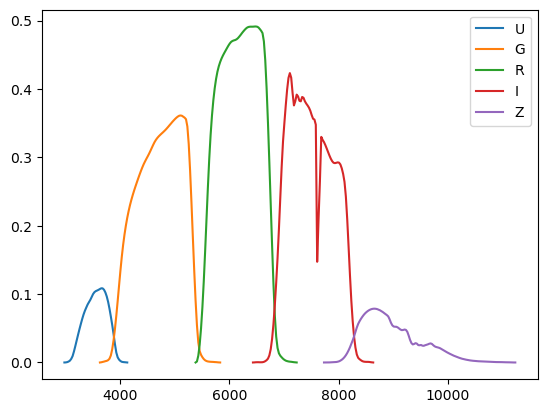

In [2]:
import emulator.interpolator.util as util
from emulator.grid_run.lc import ccd_ab_to_flux, get_sdss_flt
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np

sdss_flt = get_sdss_flt()
for name, flt in sdss_flt.items():
    plt.plot(flt['wave'], flt['trans'], label=name)
plt.legend()
plt.show()

# 2020jfo

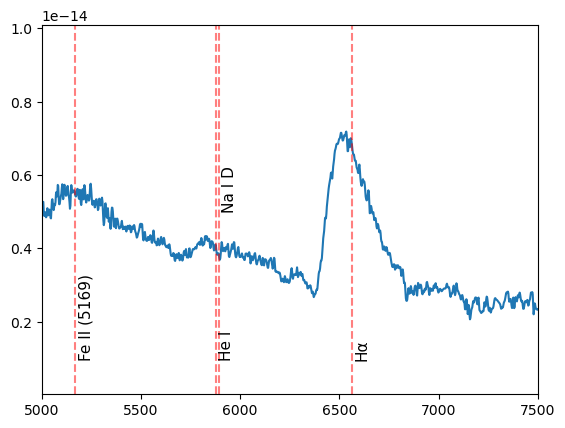

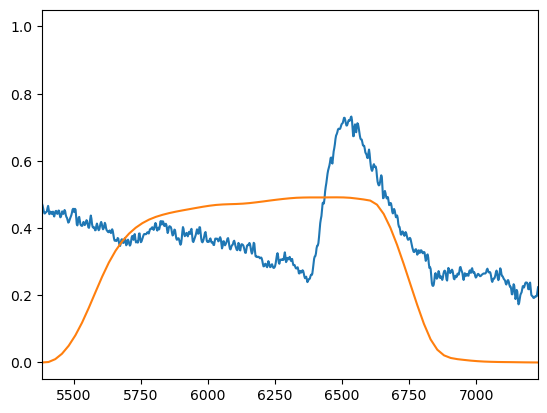

In [5]:
# Get observed data and deredshift
z = 0.005224
m_AB = 14.559
df = pd.read_csv('2020jfo-FLOYDS-S-2020-05-19.csv', comment='#')
wave = df['wavelength']
flux = df['flux']
flux_err = df['fluxerr']

flt_wave = sdss_flt['R']['wave']
flt_trans = sdss_flt['R']['trans']
obs_flux, mag_flux = ccd_ab_to_flux(m_AB, wave, flux, flt_wave, flt_trans)

calib_factor = (mag_flux / obs_flux).to(u.dimensionless_unscaled).value
flux *= calib_factor
flux_err *= calib_factor

# Write the new calibrated data, deredshift after calibration
wave /= (1 + z)
new = pd.DataFrame({'wavelength': wave, 'flux': flux, 'fluxerr': flux_err})
new.to_csv('2020jfo-2020-05-19.csv', index=False)

plt.plot(wave, flux)
plt.xlim(5000, 7500)
util.label_common_features()
plt.show()

plt.plot(wave, (flux - flux.min()) / (flux.max() - flux.min()))
plt.plot(flt_wave, flt_trans)
plt.xlim(flt_wave.min(), flt_wave.max())
plt.show()

In [ ]:
# Deredshift other flux calibrated spectra

# 2020jww
z = 0.0457
df = pd.read_csv('2020jww-KAST-2020-05-23_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020jww-2020-05-23.csv', index=False)
t_exp = 58992 - 58982
print(t_exp)

# 2020hgw
z = 0.0432
df = pd.read_csv('2020hgw-KAST-2020-05-23_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020hgw-2020-05-23.csv', index=False)
t_exp = 58992 - 58950
print(t_exp)

# 2020rth
z = 0.0184
df = pd.read_csv('2020rth-RSS-2020-08-24_calibrated.flm', names=['wavelength', 'flux'], sep=' ', index_col=False)
wav = df['wavelength']
flux = df['flux']
wav /= (1 + z)
new = pd.DataFrame({'wavelength': wav, 'flux': flux})
new.to_csv('2020rth-2020-08-24.csv', index=False)
t_exp = 59085 - 59067
print(t_exp)


10
42
18
